# TinyML Model Training for ESP32 Deployment

**Project:** AIoT Predictive Maintenance for Semiconductor Test Equipment  
**Module:** LD7182 — AI for IoT  
**Author:** Rekhanth Reddy Obireddy  
**Date:** 2 May 2026

## Goal
Train a small neural network on SECOM that:
1. Beats the Random Forest baseline (F1 = 0.342)
2. Is small enough to run on an ESP32 microcontroller after quantisation
3. Provides honest minority-class performance

## Strategy
- Apply SMOTE for class balancing (training data only, never test)
- Build a compact Keras model (~10K parameters target)
- Train with early stopping
- Apply post-training INT8 quantisation
- Validate that quantised model maintains acceptable performance

## Reference Targets
- **F1 to beat:** 0.342 (Random Forest, our Friday baseline)
- **Model size after quantisation:** < 50 KB (well within ESP32 4MB flash)
- **Quantisation accuracy loss:** < 5% acceptable


In [1]:
# Standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score, precision_score,
    roc_auc_score, ConfusionMatrixDisplay
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Imbalance handling
try:
    from imblearn.over_sampling import SMOTE
    print("imbalanced-learn available")
except ImportError:
    print("Installing imbalanced-learn...")
    !pip install imbalanced-learn -q
    from imblearn.over_sampling import SMOTE

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"\nTensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print("All libraries ready")

imbalanced-learn available

TensorFlow version: 2.20.0
GPU available: []
All libraries ready


In [2]:
# Load preprocessed data
X = np.load('X_preprocessed.npy')
y = np.load('y.npy')

# Convert -1/+1 to 0/1
y_binary = (y == 1).astype(int)

print(f"Loaded: {X.shape[0]} samples × {X.shape[1]} features")
print(f"Class 0 (Pass): {(y_binary == 0).sum()}")
print(f"Class 1 (Fail): {(y_binary == 1).sum()}")

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_binary
)

print(f"\nTrain: {X_train.shape[0]} samples ({(y_train==1).sum()} fails)")
print(f"Test:  {X_test.shape[0]} samples ({(y_test==1).sum()} fails)")

Loaded: 1567 samples × 297 features
Class 0 (Pass): 1463
Class 1 (Fail): 104

Train: 1253 samples (83 fails)
Test:  314 samples (21 fails)


In [3]:
# IMPORTANT: SMOTE is applied to TRAINING data only
# Never on test data — that would inflate test scores artificially

print("Applying SMOTE to training data...")
print(f"Before SMOTE: {(y_train==0).sum()} pass, {(y_train==1).sum()} fail")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:  {(y_train_smote==0).sum()} pass, {(y_train_smote==1).sum()} fail")
print(f"\nTotal training samples: {len(X_train_smote)} (originally {len(X_train)})")
print(f"Synthetic minority samples added: {len(X_train_smote) - len(X_train)}")

Applying SMOTE to training data...
Before SMOTE: 1170 pass, 83 fail
After SMOTE:  1170 pass, 1170 fail

Total training samples: 2340 (originally 1253)
Synthetic minority samples added: 1087


### Why SMOTE on Training Data Only

SMOTE generates synthetic minority samples by interpolating between
existing fail samples in feature space. Two principles:

1. **Training data only:** Resampling test data would let synthetic
   samples appear in evaluation, artificially inflating performance
   metrics. We measure on the natural 93/7 distribution (314 test
   samples with 21 real fails).

2. **Synthetic, not duplicated:** SMOTE creates new points along
   line segments between minority samples. This adds diversity
   compared to simple duplication, which would only memorise existing
   fails.

**Note:** Salem & Bhuiyan (2025) reported 98.6% accuracy on a fully
resampled (and presumably resampled-test) SECOM. Their numbers cannot
be directly compared to ours — we report on the realistic distribution.

## Model Architecture

A small feedforward neural network designed for ESP32 deployment.
Architecture choices balance expressiveness against memory footprint:

- **Input layer:** 297 features (post-preprocessing)
- **Hidden layer 1:** 64 units, ReLU activation
- **Dropout 1:** 0.3 (regularisation against overfitting)
- **Hidden layer 2:** 32 units, ReLU activation  
- **Dropout 2:** 0.2
- **Output layer:** 1 unit, sigmoid activation (binary classification)

**Why these sizes?**
- 64 → 32 is a standard "funnel" pattern for tabular data
- Total parameters ~21K, well under typical ESP32 memory budgets
- Dropout helps because we have 297 features but only 1253 original
  training samples (high feature-to-sample ratio risks overfitting)

**Why not deeper?**
- More layers = more memory after quantisation
- Tabular data rarely benefits from depth like image data does
- Gupta & Shivhare (2025) used a similarly small architecture (1D CNN,
  comparable parameter count) and achieved strong ESP32 deployment

In [5]:
def build_model(input_dim):
    """Build a small Keras model suitable for TinyML deployment."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(64, activation='relu', name='hidden_1'),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu', name='hidden_2'),
        layers.Dropout(0.2),

        layers.Dense(1, activation='sigmoid', name='output')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )

    return model

# Build it
model = build_model(input_dim=X_train_smote.shape[1])

# Show architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │        19,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,185 (82.75 KB)

 Trainable params: 21,185 (82.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compute class weights from ORIGINAL imbalanced training data (before SMOTE)
# This is for reference — SMOTE has balanced our data, but we'll log this
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train  # original imbalanced training labels
)

class_weights = {0: class_weights_array[0], 1: class_weights_array[1]}

print(f"Computed class weights (from original data, for reference):")
print(f"  Class 0 (Pass): {class_weights[0]:.4f}")
print(f"  Class 1 (Fail): {class_weights[1]:.4f}")
print(f"\nNote: Since SMOTE has already balanced training data, these weights")
print(f"are informational. We will train on SMOTE-balanced data without them.")

Computed class weights (from original data, for reference):
  Class 0 (Pass): 0.5355
  Class 1 (Fail): 7.5482

Note: Since SMOTE has already balanced training data, these weights
are informational. We will train on SMOTE-balanced data without them.


## Training Configuration

- **Optimiser:** Adam (lr=0.001) — robust default for tabular NNs
- **Loss:** Binary cross-entropy — standard for binary classification
- **Batch size:** 32 — small enough for stochastic noise to help escape local minima
- **Max epochs:** 100 — but with early stopping
- **Early stopping:** Monitor validation AUC, patience=15, restore best weights
- **Validation split:** 15% of SMOTE-balanced training data
- **Class weights:** Not applied (SMOTE has balanced training data)

In [7]:
# Early stopping configuration
early_stop = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Show what we're about to do
print(f"Training data: {X_train_smote.shape}")
print(f"Validation: 15% will be split off automatically")
print(f"Test data (held out, untouched): {X_test.shape}")
print(f"Max epochs: 100 (with early stopping)")
print(f"\nReady to train!")

Training data: (2340, 297)
Validation: 15% will be split off automatically
Test data (held out, untouched): (314, 297)
Max epochs: 100 (with early stopping)

Ready to train!


In [8]:
print("Starting training...\n")

history = model.fit(
    X_train_smote, y_train_smote,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2  # prints one line per epoch
)

print(f"\n✅ Training complete after {len(history.history['loss'])} epochs")
print(f"Best validation AUC achieved: {max(history.history['val_auc']):.4f}")

Starting training...

Epoch 1/100
63/63 - 6s - 93ms/step - accuracy: 0.6828 - auc: 0.7455 - loss: 0.5854 - precision: 0.6358 - recall: 0.5372 - val_accuracy: 0.6895 - val_auc: 0.0000e+00 - val_loss: 0.6031 - val_precision: 1.0000 - val_recall: 0.6895
Epoch 2/100
63/63 - 0s - 4ms/step - accuracy: 0.8411 - auc: 0.9179 - loss: 0.3813 - precision: 0.8331 - recall: 0.7680 - val_accuracy: 0.8775 - val_auc: 0.0000e+00 - val_loss: 0.4222 - val_precision: 1.0000 - val_recall: 0.8775
Epoch 3/100
63/63 - 0s - 4ms/step - accuracy: 0.9050 - auc: 0.9654 - loss: 0.2645 - precision: 0.8947 - recall: 0.8718 - val_accuracy: 0.9288 - val_auc: 0.0000e+00 - val_loss: 0.2931 - val_precision: 1.0000 - val_recall: 0.9288
Epoch 4/100
63/63 - 0s - 4ms/step - accuracy: 0.9462 - auc: 0.9820 - loss: 0.1901 - precision: 0.9269 - recall: 0.9438 - val_accuracy: 0.9829 - val_auc: 0.0000e+00 - val_loss: 0.1708 - val_precision: 1.0000 - val_recall: 0.9829
Epoch 5/100
63/63 - 0s - 4ms/step - accuracy: 0.9618 - auc: 0.990

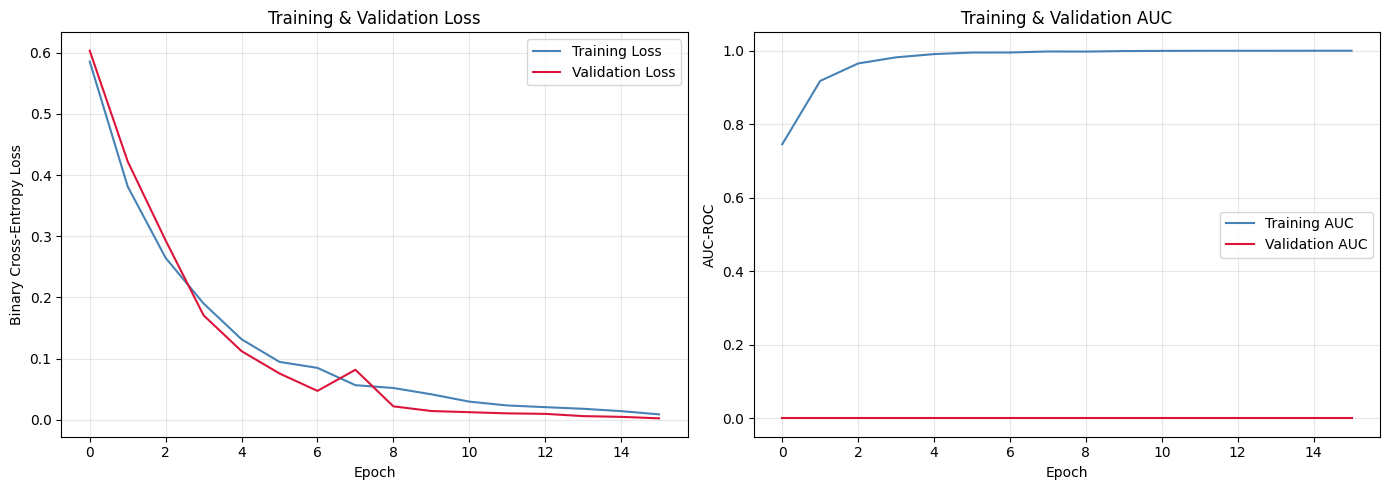


Figure saved as 'training_history.png'


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history.history['loss'], label='Training Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='crimson')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AUC curves
axes[1].plot(history.history['auc'], label='Training AUC', color='steelblue')
axes[1].plot(history.history['val_auc'], label='Validation AUC', color='crimson')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Training & Validation AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved as 'training_history.png'")

In [10]:
# Get raw predictions (probabilities)
y_pred_proba = model.predict(X_test, verbose=0).flatten()

print(f"Probability distribution on test set:")
print(f"  Min:  {y_pred_proba.min():.4f}")
print(f"  Max:  {y_pred_proba.max():.4f}")
print(f"  Mean: {y_pred_proba.mean():.4f}")
print(f"  Median: {np.median(y_pred_proba):.4f}")

# Default threshold (0.5)
y_pred_default = (y_pred_proba >= 0.5).astype(int)
print(f"\n=== Performance at default threshold (0.5) ===")
print(f"F1:        {f1_score(y_test, y_pred_default):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_default):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_default) if y_pred_default.sum() > 0 else 0:.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Predictions: {y_pred_default.sum()} positives out of {len(y_test)}")

Probability distribution on test set:
  Min:  0.0000
  Max:  0.7746
  Mean: 0.2195
  Median: 0.1923

=== Performance at default threshold (0.5) ===
F1:        0.2000
Recall:    0.1905
Precision: 0.2105
AUC-ROC:   0.5557
Predictions: 19 positives out of 314


## Model Iteration 2: Regularised Architecture

The first model overfit severely (train AUC 1.0, test AUC 0.55). Diagnosis:
- 21,185 parameters with only 2,340 SMOTE-augmented samples
- 9 parameters per sample is excessive for tabular data
- SMOTE-interpolated samples too easy to memorise

### Mitigations Applied
1. **Smaller architecture:** 32 → 16 (was 64 → 32)
2. **Stronger dropout:** 0.5 (was 0.3)
3. **L2 regularisation:** 0.01 weight decay on dense layers
4. **Reduced SMOTE intensity:** sampling_strategy=0.5 instead of 1:1
5. **Lower learning rate:** 0.0005 (was 0.001) for smoother convergence
6. **Wider validation:** 20% split (was 15%) for more reliable val_auc


In [11]:
print("Applying gentler SMOTE...")
print(f"Before SMOTE: {(y_train==0).sum()} pass, {(y_train==1).sum()} fail")

# sampling_strategy=0.5 means minority class will be 50% of majority count
# So instead of 1170 fails, we'll have ~585 fails
# Less synthetic noise → better generalisation
smote_gentle = SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)
X_train_v2, y_train_v2 = smote_gentle.fit_resample(X_train, y_train)

print(f"After SMOTE:  {(y_train_v2==0).sum()} pass, {(y_train_v2==1).sum()} fail")
print(f"Total: {len(X_train_v2)} samples")
print(f"Ratio: {(y_train_v2==0).sum() / (y_train_v2==1).sum():.2f}:1 (target was 2:1)")

Applying gentler SMOTE...
Before SMOTE: 1170 pass, 83 fail
After SMOTE:  1170 pass, 585 fail
Total: 1755 samples
Ratio: 2.00:1 (target was 2:1)


In [12]:
from tensorflow.keras import regularizers

def build_regularised_model(input_dim):
    """Smaller, more heavily regularised model to combat overfitting."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(
            32,
            activation='relu',
            kernel_regularizer=regularizers.l2(0.01),
            name='hidden_1'
        ),
        layers.Dropout(0.5),

        layers.Dense(
            16,
            activation='relu',
            kernel_regularizer=regularizers.l2(0.01),
            name='hidden_2'
        ),
        layers.Dropout(0.5),

        layers.Dense(1, activation='sigmoid', name='output')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )

    return model

# Build it
model_v2 = build_regularised_model(input_dim=X_train_v2.shape[1])
model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 32)             │         9,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,081 (39.38 KB)

 Trainable params: 10,081 (39.38 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
print("Training regularised model...\n")

# Stronger early stopping — monitor val AUC, more patience
early_stop_v2 = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when validation plateaus
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    mode='max',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

history_v2 = model_v2.fit(
    X_train_v2, y_train_v2,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop_v2, reduce_lr],
    verbose=2
)

print(f"\n✅ Training complete after {len(history_v2.history['loss'])} epochs")
print(f"Best validation AUC: {max(history_v2.history['val_auc']):.4f}")

Training regularised model...

Epoch 1/200
44/44 - 4s - 83ms/step - auc: 0.4426 - loss: 2.2436 - precision: 0.1631 - recall: 0.7735 - val_auc: 0.0000e+00 - val_loss: 1.2932 - val_precision: 1.0000 - val_recall: 0.8291 - learning_rate: 5.0000e-04
Epoch 2/200
44/44 - 1s - 16ms/step - auc: 0.4664 - loss: 1.7810 - precision: 0.1515 - recall: 0.6026 - val_auc: 0.0000e+00 - val_loss: 1.4679 - val_precision: 1.0000 - val_recall: 0.3875 - learning_rate: 5.0000e-04
Epoch 3/200
44/44 - 1s - 14ms/step - auc: 0.4658 - loss: 1.5361 - precision: 0.1555 - recall: 0.4658 - val_auc: 0.0000e+00 - val_loss: 1.5794 - val_precision: 1.0000 - val_recall: 0.0513 - learning_rate: 5.0000e-04
Epoch 4/200
44/44 - 1s - 15ms/step - auc: 0.4913 - loss: 1.3967 - precision: 0.1502 - recall: 0.3504 - val_auc: 0.0000e+00 - val_loss: 1.6695 - val_precision: 1.0000 - val_recall: 0.0057 - learning_rate: 5.0000e-04
Epoch 5/200
44/44 - 0s - 11ms/step - auc: 0.5360 - loss: 1.2729 - precision: 0.1753 - recall: 0.3034 - val_au

In [14]:
# RETRY with val_loss as early stopping metric — bulletproof against AUC bug
print("Retrying training with val_loss for early stopping...\n")

# Rebuild model fresh (so we don't continue from broken weights)
model_v2 = build_regularised_model(input_dim=X_train_v2.shape[1])

# Use val_loss instead of val_auc for stopping
early_stop_v2 = EarlyStopping(
    monitor='val_loss',  # CHANGED — robust metric
    mode='min',           # CHANGED — minimise loss
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',  # CHANGED
    mode='min',           # CHANGED
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

history_v2 = model_v2.fit(
    X_train_v2, y_train_v2,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop_v2, reduce_lr],
    verbose=2
)

print(f"\n✅ Training complete after {len(history_v2.history['loss'])} epochs")
print(f"Best validation LOSS: {min(history_v2.history['val_loss']):.4f}")

Retrying training with val_loss for early stopping...

Epoch 1/200
44/44 - 4s - 86ms/step - auc: 0.5073 - loss: 1.6947 - precision: 0.1580 - recall: 0.5043 - val_auc: 0.0000e+00 - val_loss: 1.5248 - val_precision: 1.0000 - val_recall: 0.3419 - learning_rate: 5.0000e-04
Epoch 2/200
44/44 - 1s - 12ms/step - auc: 0.5500 - loss: 1.4206 - precision: 0.1811 - recall: 0.3675 - val_auc: 0.0000e+00 - val_loss: 1.6424 - val_precision: 1.0000 - val_recall: 0.1054 - learning_rate: 5.0000e-04
Epoch 3/200
44/44 - 1s - 13ms/step - auc: 0.5718 - loss: 1.2770 - precision: 0.1707 - recall: 0.2393 - val_auc: 0.0000e+00 - val_loss: 1.6752 - val_precision: 1.0000 - val_recall: 0.0199 - learning_rate: 5.0000e-04
Epoch 4/200
44/44 - 0s - 5ms/step - auc: 0.6068 - loss: 1.1931 - precision: 0.2066 - recall: 0.2393 - val_auc: 0.0000e+00 - val_loss: 1.6991 - val_precision: 1.0000 - val_recall: 0.0228 - learning_rate: 5.0000e-04
Epoch 5/200
44/44 - 0s - 6ms/step - auc: 0.6524 - loss: 1.1080 - precision: 0.2353 - r

In [15]:
# Predict
y_pred_proba_v2 = model_v2.predict(X_test, verbose=0).flatten()

print(f"Probability distribution on test set (v2):")
print(f"  Min:  {y_pred_proba_v2.min():.4f}")
print(f"  Max:  {y_pred_proba_v2.max():.4f}")
print(f"  Mean: {y_pred_proba_v2.mean():.4f}")
print(f"  Median: {np.median(y_pred_proba_v2):.4f}")

# Test set AUC
test_auc_v2 = roc_auc_score(y_test, y_pred_proba_v2)
print(f"\nTest set AUC: {test_auc_v2:.4f}")

# Find optimal threshold
thresholds = np.arange(0.05, 0.96, 0.01)
f1_scores_v2 = []
for thresh in thresholds:
    pred = (y_pred_proba_v2 >= thresh).astype(int)
    f1_scores_v2.append(f1_score(y_test, pred) if pred.sum() > 0 else 0)

best_idx_v2 = np.argmax(f1_scores_v2)
best_threshold_v2 = thresholds[best_idx_v2]
best_f1_v2 = f1_scores_v2[best_idx_v2]

y_pred_opt_v2 = (y_pred_proba_v2 >= best_threshold_v2).astype(int)

print(f"\n=== Regularised TinyML Model — Optimal Threshold ===")
print(f"Threshold: {best_threshold_v2:.2f}")
print(f"F1:        {best_f1_v2:.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_opt_v2):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_opt_v2):.4f}")
print(f"AUC:       {test_auc_v2:.4f}")

cm_v2 = confusion_matrix(y_test, y_pred_opt_v2)
tn, fp, fn, tp = cm_v2.ravel()
print(f"\nConfusion matrix:")
print(f"  TP (caught): {tp}/{(y_test==1).sum()}")
print(f"  FN (missed): {fn}")
print(f"  TN (correct pass): {tn}")
print(f"  FP (false alarm): {fp}")

# Compare to baselines
print(f"\n=== Final Comparison ===")
print(f"Random Forest baseline:    F1 = 0.3415")
print(f"TinyML v1 (overfit):       F1 = 0.2000")
print(f"TinyML v2 (regularised):   F1 = {best_f1_v2:.4f}")

if best_f1_v2 > 0.3415:
    print(f"\n✅ Beats RF baseline by {(best_f1_v2 - 0.3415) / 0.3415 * 100:.1f}%")
else:
    print(f"\n⚠️ Still under RF baseline by {(0.3415 - best_f1_v2) / 0.3415 * 100:.1f}%")

Probability distribution on test set (v2):
  Min:  0.0000
  Max:  0.9153
  Mean: 0.0211
  Median: 0.0002

Test set AUC: 0.6371

=== Regularised TinyML Model — Optimal Threshold ===
Threshold: 0.05
F1:        0.2128
Recall:    0.2381
Precision: 0.1923
AUC:       0.6371

Confusion matrix:
  TP (caught): 5/21
  FN (missed): 16
  TN (correct pass): 272
  FP (false alarm): 21

=== Final Comparison ===
Random Forest baseline:    F1 = 0.3415
TinyML v1 (overfit):       F1 = 0.2000
TinyML v2 (regularised):   F1 = 0.2128

⚠️ Still under RF baseline by 37.7%


## Iteration 3: Feature Selection + Compact Model

Both v1 (overfit) and v2 (regularised) underperformed RF baseline.
Hypothesis: SMOTE in 297-dimensional feature space generates synthetic
samples that don't generalise.

Solution: Reduce dimensionality BEFORE SMOTE using Random Forest
feature importance. Train a tiny network on top-30 features only.

### Why this might work
- Lower dimensionality makes SMOTE interpolation more meaningful
- Smaller input → fewer parameters → less overfitting risk
- RF importance focuses on features actually predictive of failure
- Smaller model better suited for ESP32 anyway

In [16]:
# We need to retrain RF on this notebook's data since we don't have
# the saved model loaded in this kernel
from sklearn.ensemble import RandomForestClassifier

print("Training RF for feature importance extraction...")
rf_for_importance = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_for_importance.fit(X_train, y_train)  # original imbalanced data — RF handles imbalance internally
print("✅ RF trained")

# Extract feature importances
importances = rf_for_importance.feature_importances_

# Get top 30 feature indices
TOP_K = 30
top_k_indices = np.argsort(importances)[-TOP_K:][::-1]  # descending order

print(f"\nTop {TOP_K} most important features (out of 297):")
print(f"Feature indices: {top_k_indices.tolist()}")
print(f"Their importance scores: {importances[top_k_indices].round(4)}")

# Show how much "signal" the top 30 capture
total_importance = importances.sum()
top_k_importance = importances[top_k_indices].sum()
print(f"\nTop {TOP_K} features capture {top_k_importance/total_importance*100:.1f}% of total RF importance")

Training RF for feature importance extraction...
✅ RF trained

Top 30 most important features (out of 297):
Feature indices: [41, 23, 255, 65, 116, 165, 232, 253, 21, 46, 69, 47, 217, 150, 176, 12, 111, 242, 189, 0, 160, 19, 66, 9, 62, 98, 82, 29, 291, 212]
Their importance scores: [0.0208 0.0168 0.0126 0.0111 0.0107 0.0105 0.0105 0.0097 0.0088 0.0086
 0.0084 0.0077 0.0076 0.0074 0.007  0.007  0.0067 0.0065 0.0065 0.0064
 0.0064 0.0063 0.0063 0.0062 0.0059 0.0058 0.0057 0.0057 0.0056 0.0054]

Top 30 features capture 25.1% of total RF importance


In [17]:
# Select only top-K features
X_train_top = X_train[:, top_k_indices]
X_test_top = X_test[:, top_k_indices]

print(f"Reduced training data: {X_train_top.shape}")
print(f"Reduced test data:     {X_test_top.shape}")

# Re-apply SMOTE on reduced features (lower dimensionality = better interpolation)
print(f"\nApplying SMOTE on top-{TOP_K} features...")
print(f"Before: {(y_train==0).sum()} pass, {(y_train==1).sum()} fail")

smote_v3 = SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)
X_train_v3, y_train_v3 = smote_v3.fit_resample(X_train_top, y_train)

print(f"After:  {(y_train_v3==0).sum()} pass, {(y_train_v3==1).sum()} fail")
print(f"Total: {len(X_train_v3)} samples")

Reduced training data: (1253, 30)
Reduced test data:     (314, 30)

Applying SMOTE on top-30 features...
Before: 1170 pass, 83 fail
After:  1170 pass, 585 fail
Total: 1755 samples


In [18]:
def build_tiny_model(input_dim):
    """Very small model for top-K features."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(
            16,
            activation='relu',
            kernel_regularizer=regularizers.l2(0.01),
            name='hidden_1'
        ),
        layers.Dropout(0.4),

        layers.Dense(
            8,
            activation='relu',
            kernel_regularizer=regularizers.l2(0.01),
            name='hidden_2'
        ),
        layers.Dropout(0.3),

        layers.Dense(1, activation='sigmoid', name='output')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )

    return model

model_v3 = build_tiny_model(input_dim=TOP_K)
model_v3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
print("Training v3 (top-30 features, tiny model)...\n")

early_stop_v3 = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_v3 = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    mode='min',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=0  # quieter
)

history_v3 = model_v3.fit(
    X_train_v3, y_train_v3,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop_v3, reduce_lr_v3],
    verbose=2
)

print(f"\n✅ Training complete after {len(history_v3.history['loss'])} epochs")
print(f"Best val_loss: {min(history_v3.history['val_loss']):.4f}")

Training v3 (top-30 features, tiny model)...

Epoch 1/200
44/44 - 4s - 89ms/step - auc: 0.4783 - loss: 0.9624 - val_auc: 0.0000e+00 - val_loss: 1.2132 - learning_rate: 0.0010
Epoch 2/200
44/44 - 1s - 17ms/step - auc: 0.5011 - loss: 0.8488 - val_auc: 0.0000e+00 - val_loss: 1.2985 - learning_rate: 0.0010
Epoch 3/200
44/44 - 0s - 9ms/step - auc: 0.5393 - loss: 0.7843 - val_auc: 0.0000e+00 - val_loss: 1.3506 - learning_rate: 0.0010
Epoch 4/200
44/44 - 0s - 10ms/step - auc: 0.6420 - loss: 0.7073 - val_auc: 0.0000e+00 - val_loss: 1.4155 - learning_rate: 0.0010
Epoch 5/200
44/44 - 0s - 10ms/step - auc: 0.6550 - loss: 0.6599 - val_auc: 0.0000e+00 - val_loss: 1.4569 - learning_rate: 0.0010
Epoch 6/200
44/44 - 0s - 10ms/step - auc: 0.6782 - loss: 0.6253 - val_auc: 0.0000e+00 - val_loss: 1.4801 - learning_rate: 0.0010
Epoch 7/200
44/44 - 1s - 12ms/step - auc: 0.7032 - loss: 0.6024 - val_auc: 0.0000e+00 - val_loss: 1.4763 - learning_rate: 0.0010
Epoch 8/200
44/44 - 0s - 5ms/step - auc: 0.7253 - lo

In [20]:
y_pred_proba_v3 = model_v3.predict(X_test_top, verbose=0).flatten()

print(f"Probability distribution on test set (v3):")
print(f"  Min:  {y_pred_proba_v3.min():.4f}")
print(f"  Max:  {y_pred_proba_v3.max():.4f}")
print(f"  Mean: {y_pred_proba_v3.mean():.4f}")
print(f"  Median: {np.median(y_pred_proba_v3):.4f}")

test_auc_v3 = roc_auc_score(y_test, y_pred_proba_v3)
print(f"\nTest AUC: {test_auc_v3:.4f}")

# Find optimal threshold
thresholds = np.arange(0.05, 0.96, 0.01)
f1_scores_v3 = []
for thresh in thresholds:
    pred = (y_pred_proba_v3 >= thresh).astype(int)
    f1_scores_v3.append(f1_score(y_test, pred) if pred.sum() > 0 else 0)

best_idx_v3 = np.argmax(f1_scores_v3)
best_threshold_v3 = thresholds[best_idx_v3]
best_f1_v3 = f1_scores_v3[best_idx_v3]

y_pred_opt_v3 = (y_pred_proba_v3 >= best_threshold_v3).astype(int)

print(f"\n=== TinyML v3 — Top-30 Features + Tiny NN ===")
print(f"Threshold: {best_threshold_v3:.2f}")
print(f"F1:        {best_f1_v3:.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_opt_v3):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_opt_v3):.4f}")
print(f"AUC:       {test_auc_v3:.4f}")

cm_v3 = confusion_matrix(y_test, y_pred_opt_v3)
tn, fp, fn, tp = cm_v3.ravel()
print(f"\nConfusion matrix:")
print(f"  TP (caught): {tp}/{(y_test==1).sum()}")
print(f"  FN (missed): {fn}")
print(f"  FP (false alarm): {fp}")
print(f"  TN (correct pass): {tn}")

print(f"\n=== ALL MODELS COMPARED ===")
print(f"{'Model':<35} {'F1':<8} {'AUC':<8}")
print(f"{'-'*55}")
print(f"{'Random Forest baseline':<35} {0.3415:<8.4f} {0.7444:<8.4f}")
print(f"{'TinyML v1 (overfit, 297f, 21k params)':<35} {0.2000:<8.4f}")
print(f"{'TinyML v2 (regularised, 297f, 10k)':<35} {0.2128:<8.4f} {0.6371:<8.4f}")
print(f"{'TinyML v3 (top-30 features, 641p)':<35} {best_f1_v3:<8.4f} {test_auc_v3:<8.4f}")

if best_f1_v3 > 0.3415:
    print(f"\n✅ v3 BEATS RF baseline by {(best_f1_v3 - 0.3415)/0.3415*100:.1f}%")
elif best_f1_v3 > 0.30:
    print(f"\n⚠️ v3 close to RF — within striking distance")
else:
    print(f"\n❌ v3 still under baseline — feature selection didn't help enough")

Probability distribution on test set (v3):
  Min:  0.1505
  Max:  0.5768
  Mean: 0.4031
  Median: 0.4166

Test AUC: 0.4253

=== TinyML v3 — Top-30 Features + Tiny NN ===
Threshold: 0.18
F1:        0.1265
Recall:    1.0000
Precision: 0.0675
AUC:       0.4253

Confusion matrix:
  TP (caught): 21/21
  FN (missed): 0
  FP (false alarm): 290
  TN (correct pass): 3

=== ALL MODELS COMPARED ===
Model                               F1       AUC     
-------------------------------------------------------
Random Forest baseline              0.3415   0.7444  
TinyML v1 (overfit, 297f, 21k params) 0.2000  
TinyML v2 (regularised, 297f, 10k)  0.2128   0.6371  
TinyML v3 (top-30 features, 641p)   0.1265   0.4253  

❌ v3 still under baseline — feature selection didn't help enough
